In [1]:
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from plot_utils import *
import flowi

%matplotlib inline
%load_ext autoreload
%autoreload 2

/Users/rstiskalek/Projects/FlowIntegrator/venv_flowi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


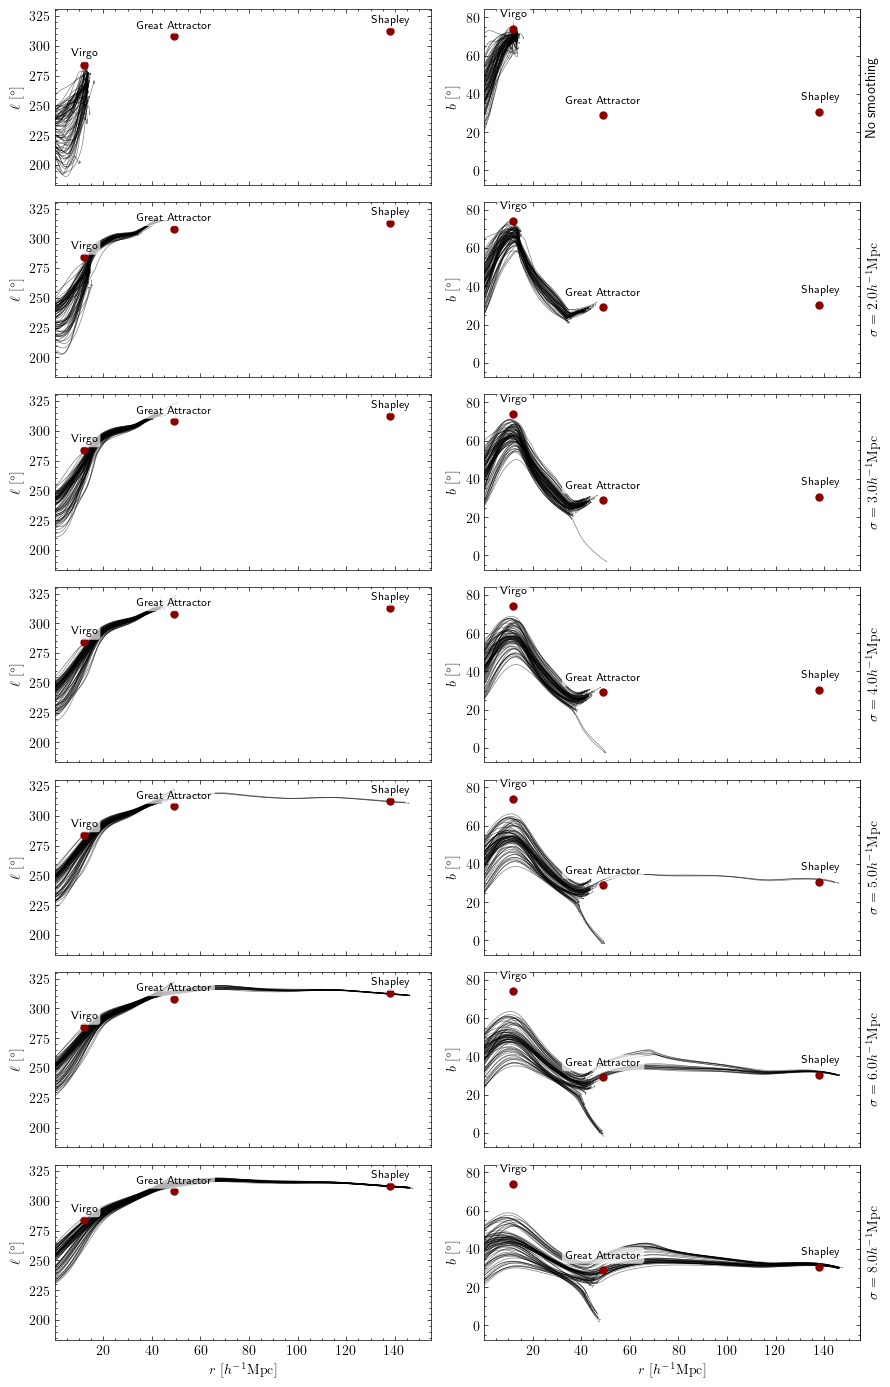

In [2]:
fname = "/Users/rstiskalek/Projects/FlowIntegrator/results/MW_streamlines.hdf5"
smoothing_scales = [0, 2, 3, 4, 5, 6, 8]
downsample = None


fig, axs = plot_mw_streamlines(fname, smoothing_scales, downsample=downsample)

# fig.savefig("/Users/rstiskalek/Downloads/mw_streamlines_smoothing.pdf", dpi=300)

display(fig)

$\sigma=2.0\ h^{-1}\ \mathrm{Mpc}$: r = 41 -6.37/+2.01; ell = 313 -7.76/+1.36; b = 27.3 -4.13/+1.4
$\sigma=3.0\ h^{-1}\ \mathrm{Mpc}$: r = 41.3 -4.66/+2.01; ell = 313 -4.76/+1.07; b = 27.4 -4.33/+1.75
$\sigma=4.0\ h^{-1}\ \mathrm{Mpc}$: r = 41.8 -3.47/+1.46; ell = 312 -2.3/+1.25; b = 26.7 -4.56/+2.46


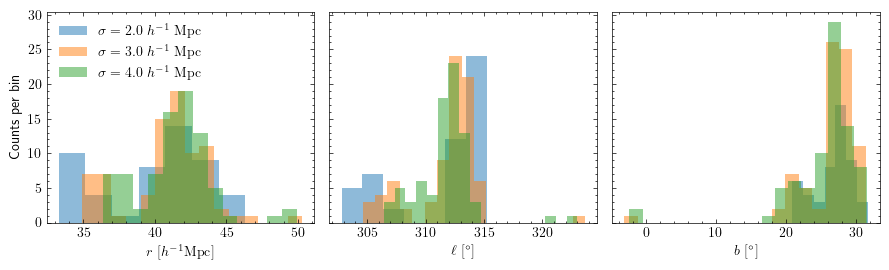

In [116]:
fnames = ["../results/ga_positions_sigma_2.0.txt",
          "../results/ga_positions_sigma_3.0.txt",
          "../results/ga_positions_sigma_4.0.txt",
          ]


# fnames = [f"../results/ga_positions_sigma_{i:.1f}.txt" for i in range(7, 10)]

fig, ax = plot_ga_positions(fnames, 681., r_min=22.5, kde=False)
# fig.savefig("/Users/rstiskalek/Downloads/ga_positions.pdf", dpi=300)
display(fig)

In [ ]:
pos = np.genfromtxt("../results/ga_positions_sigma_3.0.txt")[:, 1:]
center = np.full(3, 681/2)

# pos = flowi.cartesian_icrs_to_galactic_spherical(pos, center)
ga_position = np.array([310.20243187, 327.82457008, 317.06044731])

In [81]:
np.linalg.norm(pos - ga_position, axis=-1)

array([ 5.33395   ,  1.17794072,  3.79476388,  7.47126503,  1.29299525,
        6.70523629,  1.03763381,  2.83538326,  5.39262419,  2.08864863,
        5.69362693,  0.9723521 ,  1.75295011,  1.4442667 ,  1.48744852,
        6.35114544,  1.20871789,  2.50879019,  0.28884094,  4.49567296,
        7.45572499,  2.76345829,  4.3283879 ,  1.73030868,  2.06941702,
        7.59081568,  1.2345752 ,  3.59446047,  1.85123263,  2.4628046 ,
        6.66399576,  1.48902612,  2.2911277 ,  1.63758945,  4.14579574,
        5.79535311,  0.42067316,  3.21527921,  2.05522727,  2.20518778,
        6.07412833,  3.51826162,  3.7986019 ,  1.44147109,  4.25454883,
        6.43392513,  0.8323795 ,  1.14370824,  1.16151649,  3.6635164 ,
        7.44333933,  3.71383853,  2.80358928,  0.43192528,  3.7647016 ,
       26.70253493,  0.59261263,  1.16970946,  2.14707358,  3.36314344,
        7.45345189,  1.52999441,  2.16995169,  0.81260918,  0.65003808,
        7.11798087,  0.6206436 ,  0.89290431,  5.71307247,  1.81

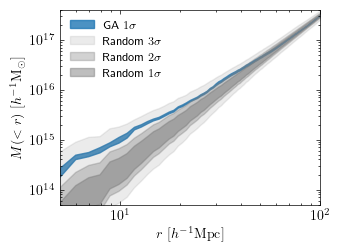

In [74]:
fname = "/Users/rstiskalek/Projects/FlowIntegrator/results/GA_enclosed_mass.hdf5"


fig, ax = plot_ga_enclosed_mass(fname)
fig.savefig("/Users/rstiskalek/Downloads/ga_enclosed_mass.pdf", dpi=300, bbox_inches="tight")
display(fig)

In [123]:
fname = "/Users/rstiskalek/Projects/FlowIntegrator/results/GA_analysis.hdf5"

sigma, M = load_ga_metrics(fname, value="ga_mass")
sigma, V = load_ga_metrics(fname, value="ga_volume")

logM = np.log10(M)

R = (V * 3 / (4 * np.pi)) ** (1/3)

In [129]:
sigma

array([ 0.,  2.,  4., 16.])

M [4.0 Mpc/h] = 16.378 (+0.081/-0.037)
R [4.0 Mpc/h] = 42.140 (+3.08/-0.788)


/var/folders/kv/90qm_jx508j4zhvy56lhf09m0000gn/T/ipykernel_17324/2971711525.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


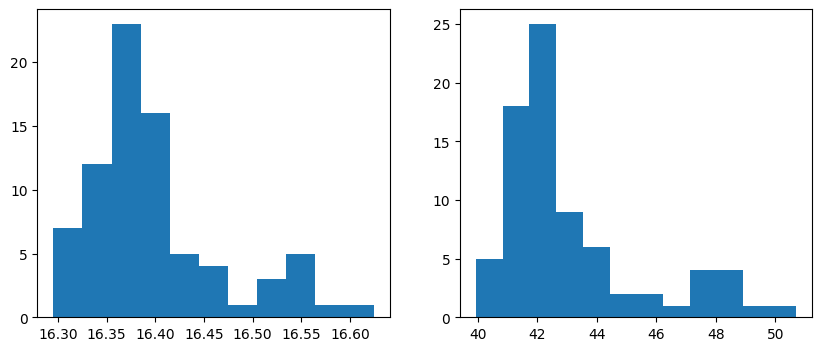

In [131]:
k = 2

print(f"M [{sigma[k]:.1f} Mpc/h] = {np.nanpercentile(logM[:, k], 50):.3f} (+{np.nanpercentile(logM[:, k], 84)-np.nanpercentile(logM[:, k], 50):.3f}/-{np.nanpercentile(logM[:, k], 50)-np.nanpercentile(logM[:, k], 16):.3f})")
print(f"R [{sigma[k]:.1f} Mpc/h] = {np.nanpercentile(R[:, k], 50):.3f} (+{np.nanpercentile(R[:, k], 84)-np.nanpercentile(R[:, k], 50):.3}/-{np.nanpercentile(R[:, k], 50)-np.nanpercentile(R[:, k], 16):.3f})")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(np.log10(M[:, k]), bins="auto")
ax[1].hist(R[:, k], bins="auto")

fig.show()


In [118]:
ra = 187.697083
dec = 12.336944


flowi.radec_to_galactic(ra, dec)

(np.float64(283.80738728835604), np.float64(74.43686740194173))